# Tutorial 
This notebook shows how to run the full PCR Simulation in a location of interest 

In [ ]:
# import modules 
import os 

from ipyleaflet import Map, basemaps
from ipywidgets import Layout

import numpy as np 
import pcr.visualisation as viz

from pcr.builder import build_model
from pcr.model import PCRModel
from dotenv import load_dotenv

# set up a seed 
np.random.seed(42)

# load API Key  
load_dotenv()
cds_api_key = os.getenv('CDS-API-KEY')

## Select a location of interest 
PCR model builder require a bounding box to build the model input. A bounding box is a list of `[longitude_min, latitude_min, longitude_max, latitude_max]`. To help acquire the coordinates, we can use `ipyleaflet` `Map` and extract the extent of the `Map` as the bounding box. 
Zoom in the widget to area of interest, wait the rendering process finished and extract the map extent 

In [ ]:
# render map and zoom in to the area of interest
m = Map(
    basemap=basemaps.Esri.WorldImagery,
    scroll_wheel_zoom=True,
    center=(7.6031203577833315, 81.77331084939762),
    zoom=12,
    layout=Layout(width='800px', height='500px')
)

m

In [ ]:
# extract the map extent, run after the map fully rendered 
bbox = [m.west, m.south, m.east, m.north]
bbox

## Build `model` from bounding box (`bbox`)
RR: build very minimal input -> tapi itu nanti aja karena sekarang masih butuh banyak adjustment 

In [ ]:
# define the general configuration of the model
model = build_model(
    # general config 
    year_start=2020,      # simulation will start at 1st of January on `year_start`
    year_end=2119,        # simulation will end at 31st of December on `year_end`
    nr_simulation=100_000,# number of monte carlo simulation, you can always adjust it before run the simulation 
    bbox=bbox,            # bounding box [longitude_min, latitude_min, longitude_max, latitude_max]
    # SLR 
    scenario='ssp126',         # for calibration, you can always adjust it before run the simulation 
    wl0=0.0,              # initial water level 
    # erosion 
    rec_rate=None,        # recover rate in m/days, assuming we don't know the recovery rate yet set it to `None` and do calibration run
    calibrate=True,       # True for runnning a calibration run 
    m=0.024,              # mean beach slope
    c1=2.046,             # empirical coefficient for Mendoza-Jimenez erosion model 
    c2=0.800,             # empirical coefficient for Mendoza-Jimenez erosion model
    # storm detection threshold 
    ts_hs=95,             # threshold percentile of significant wave height to define a storm in percentage (e.g., 95 for 95th percentile), 
                          # option to pass value instead of percentile, pass `ts_hs_type = 'value'`
    ts_dur=12.0,          # threshold of storm duration in hours 
    ts_between=48.0,      # threshold between two independent storms 
    # post-process statistics 
    statistics_kind='min',# record annual most-landward coastline position (available option: 'min', 'max', 'mean')
    # Wave data access  
    cds_api_key=cds_api_key  # API Key for CDS data platform 
)

In [ ]:
model.days_ar6

In [ ]:
# run the simulation 
model.run_simulation()

In [ ]:
ax = viz.plot_exceedance(
    model=model
)

# Module Description
PCR module in python now consist of three different type of modules, builder, model, and visualisation. 
`pcr.builder` wrap smaller module such as `pcr.io`, `pcr.calibration` and `pcr.geo` to build a model instance. `pcr.model` wrap modules that perform calculation step on PCR framework, such as `pcr.storm`, `pcr.calibration`, `pcr.shoreline`, `pcr.slr`, `pcr.erosion` and small helper module `pcr.helper`. `PCRModel` in `pcr.model` is a class that define one model instance and has `PCRModel.run_simulation()` method to run the simulation. `pcr.visualisation` contains function to visualise the model output, such as creating exceedance plot. 

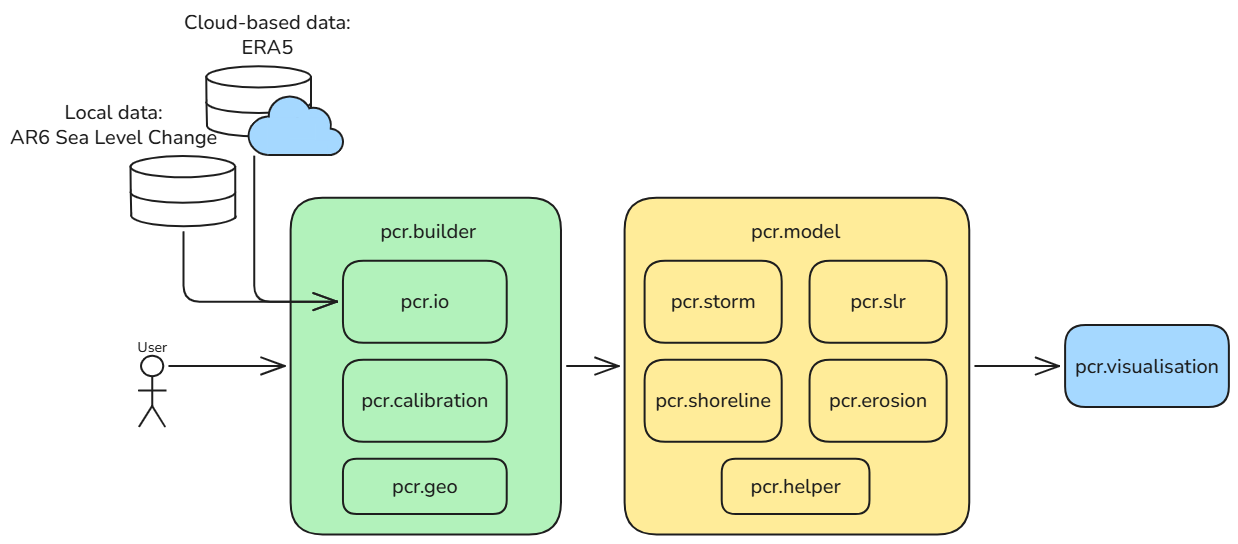

## PCR Builder 
Builder module has function called `build_model` which return to a `PCRModel` object. `build_model` will build a model based on passed `bbox`

In [ ]:
import holoviews as hv 
import shapely 

import hvplot.pandas #noqa
import geopandas as gpd

In [ ]:
box = gpd.GeoDataFrame(
    geometry=[shapely.box(*bbox)], 
    crs='EPSG:4326'
).hvplot(
    geo=True, 
    tiles='EsriImagery', 
    line_color='red', 
    color=None
)

transect = gpd.GeoDataFrame(
    [model.transect], 
    crs='EPSG:4326'
).hvplot(
    geo=True, 
    tiles='EsriImagery',
    color='yellow'
)

box * transect

In [ ]:
#TODO: step by step demonstrate the spatial look up to the model 